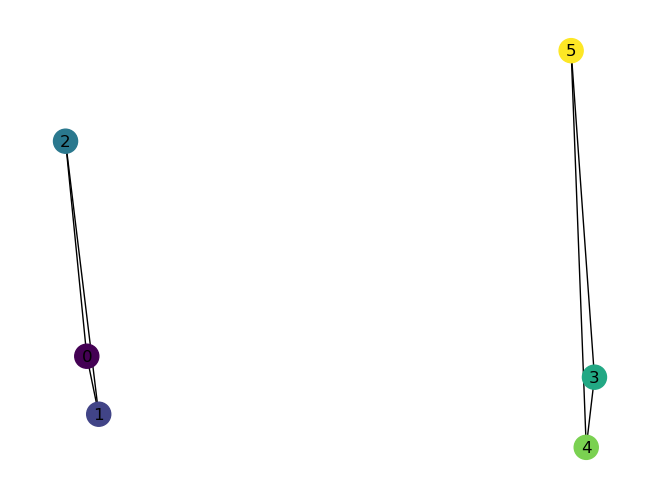

In [1]:
import networkx as nx
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def fastRP(G, dim=8, k=4):
    A = nx.to_numpy_array(G)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(1) + 1e-8))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt
    Z = np.zeros((A.shape[0], dim))
    X = np.random.randn(A.shape[0], dim)
    for i in range(1, k+1):
        X = A_hat @ X
        Z += X
    return Z

# Example: two triangles
G = nx.disjoint_union(nx.complete_graph(3), nx.complete_graph(3))
emb = fastRP(G, dim=8)
pca = PCA(n_components=2).fit_transform(emb)

nx.draw(G, pos={i: pca[i] for i in range(len(G))}, with_labels=True, node_color=range(len(G)))
plt.show()


/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


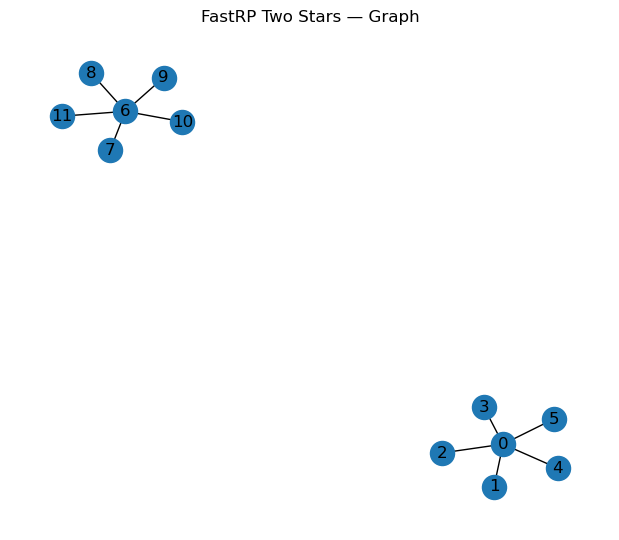

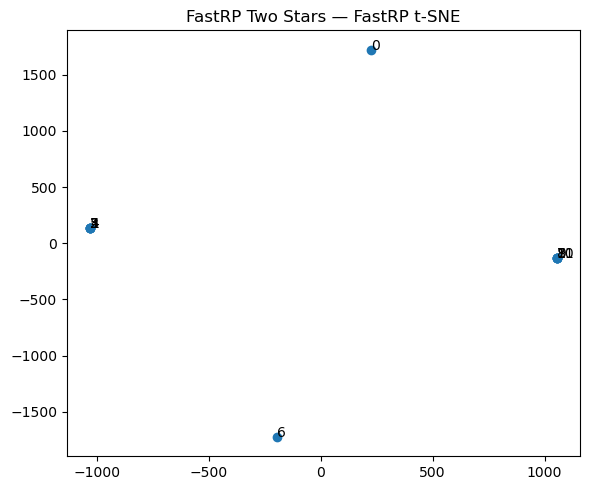

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


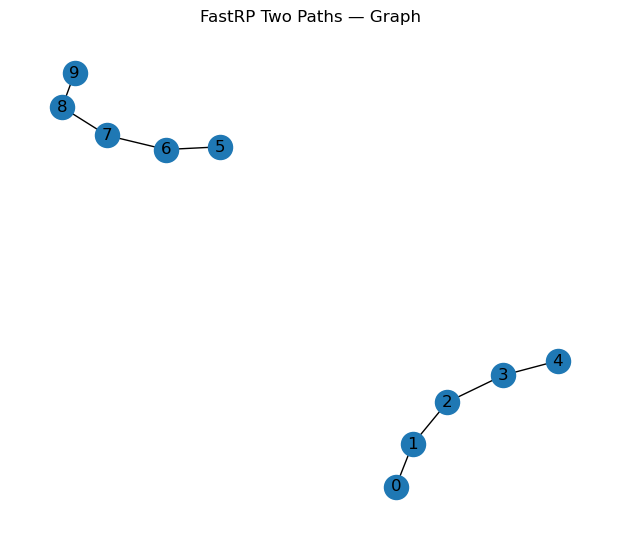

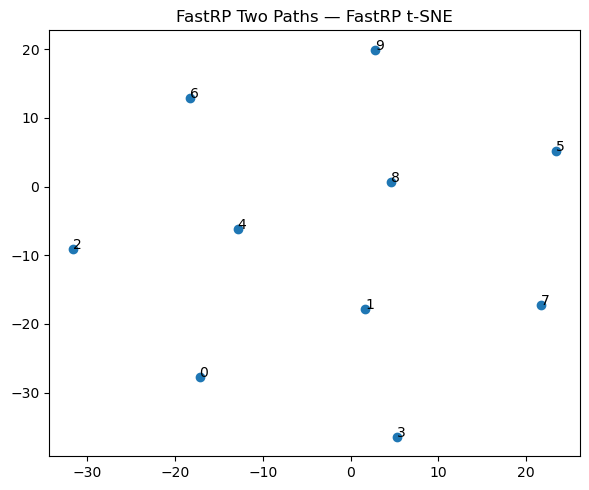

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


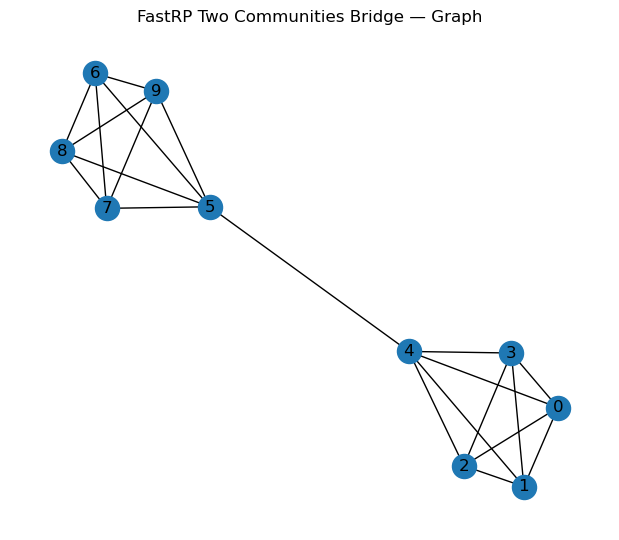

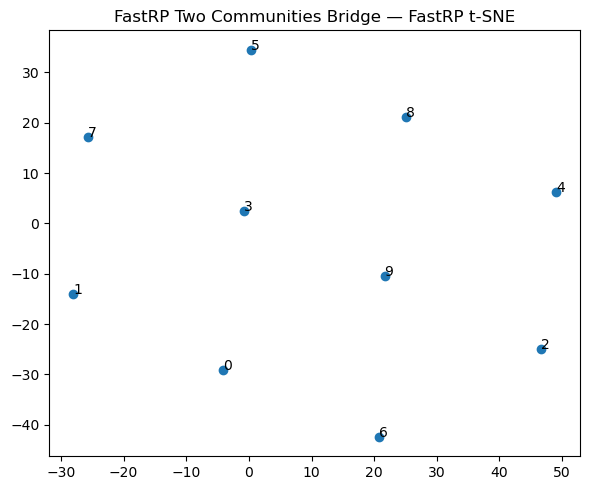

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


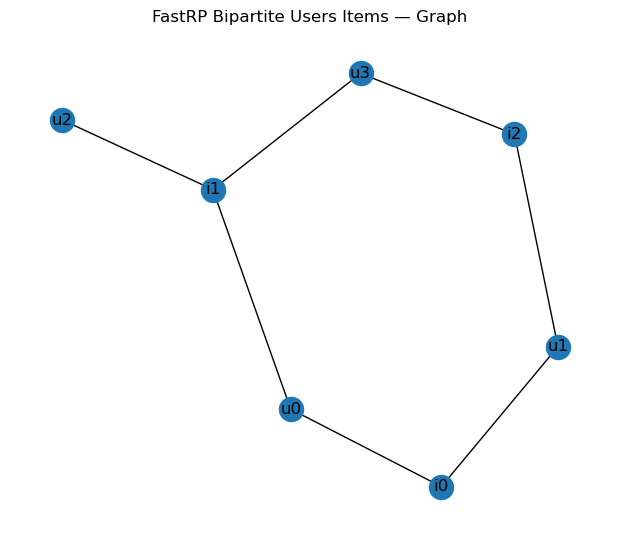

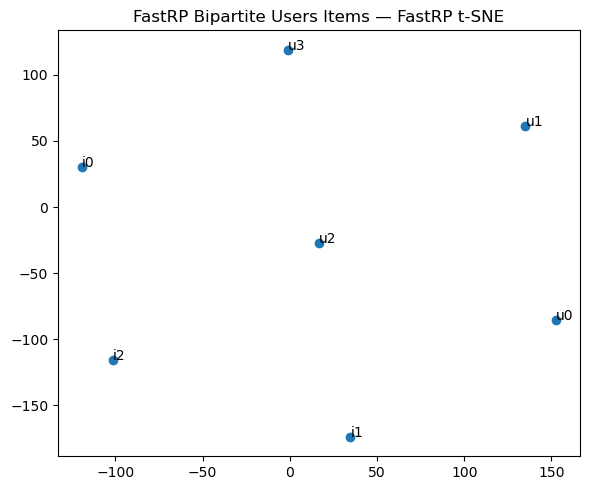

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


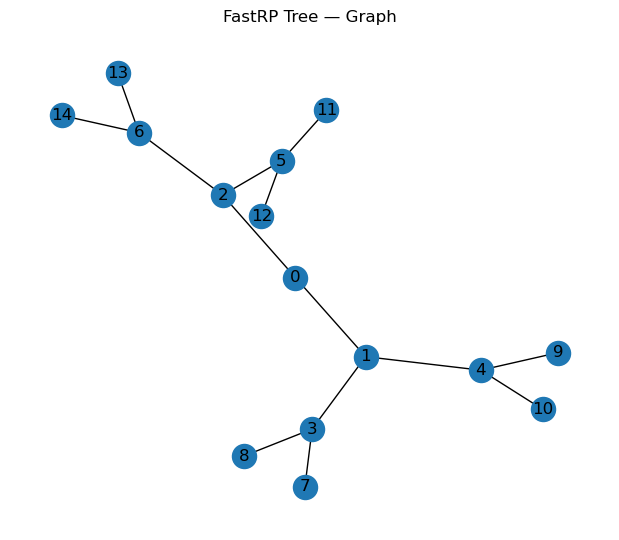

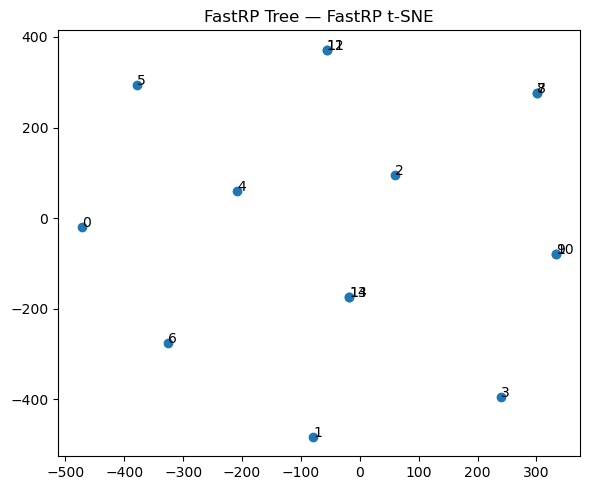

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


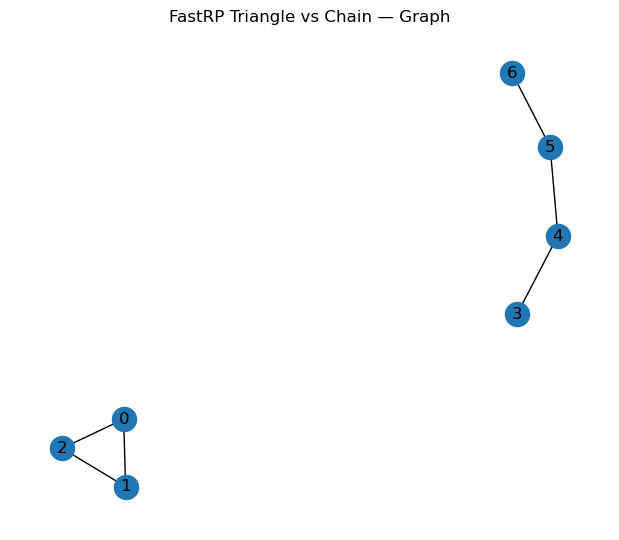

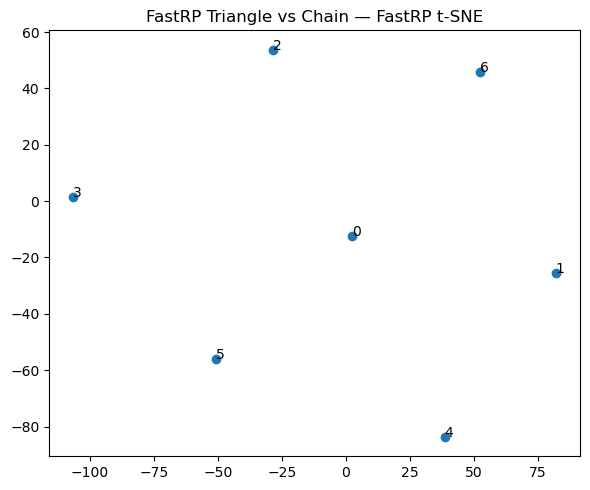

/tmp/ipykernel_714386/485275091.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


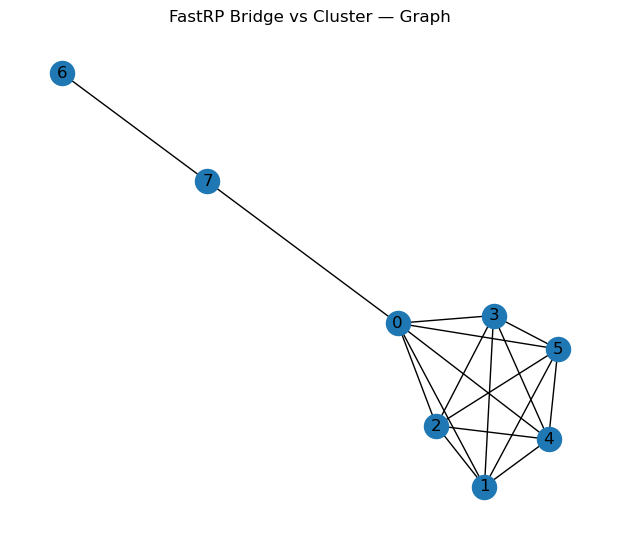

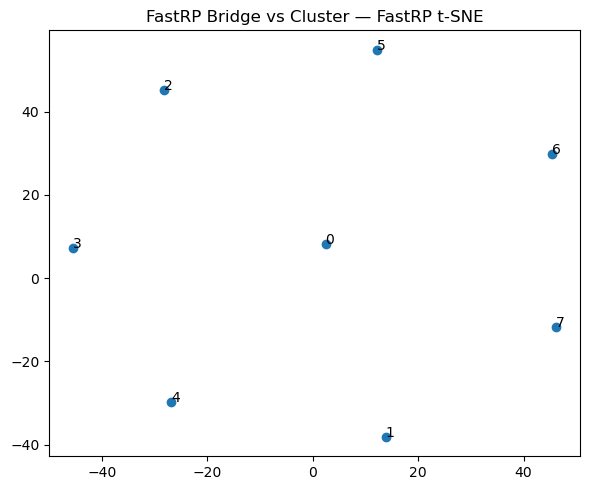

✅ All figures saved under /mnt/data/


In [4]:
# -*- coding: utf-8 -*-
"""
FastRP toy examples:
Generate illustrative graphs, compute simple FastRP embeddings,
and visualize both the graph and t-SNE projection side by side (as separate PNGs).
"""

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------- Core utilities ----------
def fastRP_embedding(G: nx.Graph, dim: int = 16, k: int = 4, seed: int = 0):
    """
    Minimal FastRP-style embedding:
      Z = sum_{i=1..k} (D^{-1/2} A D^{-1/2})^i R
    where R is a random projection matrix.
    """
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes)
    deg = A.sum(1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8))
    A_hat = D_inv_sqrt @ A @ D_inv_sqrt

    R = rng.standard_normal((A.shape[0], dim))
    Z = np.zeros_like(R)
    X = R.copy()
    for _ in range(k):
        X = A_hat @ X
        Z += X
    norms = np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12
    Z = Z / norms
    return nodes, Z


def tsne_2d(Z: np.ndarray, seed: int = 0):
    perplexity = max(5, min(20, Z.shape[0] - 1))
    tsne = TSNE(
        n_components=2,
        random_state=seed,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto"
    )
    return tsne.fit_transform(Z)


def draw_graph(G, title, filename, seed=0):
    pos = nx.spring_layout(G, seed=seed)
    plt.figure(figsize=(6, 5))
    nx.draw(G, pos=pos, with_labels=True)
    plt.title(title)
    plt.tight_layout()
    # plt.savefig(filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()


def draw_tsne(nodes, coords_2d, title, filename):
    plt.figure(figsize=(6, 5))
    x, y = coords_2d[:, 0], coords_2d[:, 1]
    plt.scatter(x, y)
    for i, n in enumerate(nodes):
        plt.text(x[i], y[i], str(n))
    plt.title(title)
    plt.tight_layout()
    # plt.savefig(filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()


def embed_and_plot(G, basename, dim=16, k=4, seed=0):
    # 1. Graph figure
    draw_graph(G, f"{basename} — Graph",
               f"/mnt/data/{basename.lower().replace(' ', '_')}_graph.png",
               seed=seed)

    # 2. t-SNE projection of FastRP embeddings
    nodes, Z = fastRP_embedding(G, dim=dim, k=k, seed=seed)
    coords = tsne_2d(Z, seed=seed)
    draw_tsne(nodes, coords, f"{basename} — FastRP t-SNE",
              f"/mnt/data/{basename.lower().replace(' ', '_')}_tsne.png")


# ---------- Example 1: Two stars ----------
def example_two_stars():
    S1 = nx.star_graph(5)               # 0..5
    S2 = nx.relabel_nodes(nx.star_graph(5), lambda x: x + 6)  # 6..11
    G = nx.disjoint_union(S1, S2)
    embed_and_plot(G, "FastRP Two Stars")


# ---------- Example 2: Two paths ----------
def example_two_paths():
    P1 = nx.path_graph(5)               # 0..4
    P2 = nx.relabel_nodes(nx.path_graph(5), lambda x: x + 5)  # 5..9
    G = nx.disjoint_union(P1, P2)
    embed_and_plot(G, "FastRP Two Paths")


# ---------- Example 3: Two communities + bridge ----------
def example_two_communities_bridge():
    C1 = nx.complete_graph(5)           # 0..4
    C2 = nx.relabel_nodes(nx.complete_graph(5), lambda x: x + 5)  # 5..9
    G = nx.disjoint_union(C1, C2)
    G.add_edge(4, 5)                    # bridge
    embed_and_plot(G, "FastRP Two Communities Bridge")


# ---------- Example 4: Bipartite (users-items) ----------
def example_bipartite():
    B = nx.Graph()
    users = [f"u{i}" for i in range(4)]
    items = [f"i{j}" for j in range(3)]
    B.add_nodes_from(users, bipartite=0)
    B.add_nodes_from(items, bipartite=1)
    edges = [
        ("u0", "i0"), ("u0", "i1"),
        ("u1", "i0"), ("u1", "i2"),
        ("u2", "i1"),
        ("u3", "i1"), ("u3", "i2")
    ]
    B.add_edges_from(edges)
    embed_and_plot(B, "FastRP Bipartite Users Items")


# ---------- Example 5: Tree (hierarchy) ----------
def example_tree():
    T = nx.balanced_tree(r=2, h=3)
    embed_and_plot(T, "FastRP Tree")


# ---------- Example 6: Triangle vs Chain ----------
def example_triangle_vs_chain():
    tri = nx.complete_graph(3)
    path = nx.relabel_nodes(nx.path_graph(4), lambda x: x + 3)
    G = nx.disjoint_union(tri, path)
    embed_and_plot(G, "FastRP Triangle vs Chain")


# ---------- Example 7: Bridge vs Cluster ----------
def example_bridge_vs_cluster():
    C = nx.complete_graph(6)
    C.add_edge(6, 7)
    C.add_edge(7, 0)
    embed_and_plot(C, "FastRP Bridge vs Cluster")


# ---------- Run all ----------
example_two_stars()
example_two_paths()
example_two_communities_bridge()
example_bipartite()
example_tree()
example_triangle_vs_chain()
example_bridge_vs_cluster()

print("✅ All figures saved under /mnt/data/")
